<a href="https://colab.research.google.com/github/Abiodun360of/graph-transformer-geoai/blob/main/%F0%9F%8C%8D_Graph_Transformer_GeoAI_Flood_Risk_Prediction_PHASE_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Graph-Transformer GeoAI: Flood Risk Prediction
## Phase 1: Study Area Setup & Data Acquisition
**Study Area:** Lokoja LGA, Kogi State, Nigeria (Niger-Benue Confluence)

**Data Sources:**
- Sentinel-1 SAR (flood detection)
- Sentinel-2 Multispectral (NDVI, NDWI, land cover)
- SRTM DEM (elevation/slope)
- JRC Global Surface Water (flood labels)
- OpenStreetMap (graph edges: roads, rivers)

**Author:** Ofobutu Abiodun Emmanuel


## 📦 Step 1: Install Dependencies

In [ ]:
# Install all required packages
!pip install earthengine-api geemap geopandas osmnx rasterio shapely folium matplotlib seaborn tqdm -q
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118 -q
!pip install torch-geometric -q
!pip install pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cu118.html -q

print('✅ All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.4 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib
✅ All packages installed


## 🔐 Step 2: Authenticate Google Earth Engine

In [ ]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='abujagee')

print('✅ Earth Engine authenticated')

✅ Earth Engine authenticated


## 🗺️ Step 3: Define Study Area — Lokoja, Kogi State

In [ ]:
import ee
import geemap
import numpy as np
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# STUDY AREA: Lokoja + Niger-Benue Confluence Buffer
# Coordinates: ~6.74°N, 6.74°E (Lokoja city center)
# Bounding box covers confluence + flood-prone lowlands
# ============================================================

# Define bounding box (approx 80km x 80km around confluence)
STUDY_AREA = {
    'lon_min': 6.4,
    'lon_max': 7.1,
    'lat_min': 7.4,
    'lat_max': 8.1,
    'name': 'Lokoja_Kogi_Nigeria'
}

# Create EE geometry
aoi = ee.Geometry.Rectangle([
    STUDY_AREA['lon_min'],
    STUDY_AREA['lat_min'],
    STUDY_AREA['lon_max'],
    STUDY_AREA['lat_max']
])

# Visualize study area
Map = geemap.Map(center=[7.75, 6.75], zoom=9)
Map.addLayer(aoi, {'color': 'red'}, 'Study Area (Lokoja, Kogi)')
Map.addLayerControl()
Map


Map(center=[7.75, 6.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

## 🛰️ Step 4: Load Sentinel-1 SAR Data (Flood Detection)

In [ ]:
# ============================================================
# SENTINEL-1 SAR — FIXED VERSION
# Problem: Kogi State is covered by ASCENDING orbit, not DESCENDING
# Fix: Auto-detect available orbit pass + widen date range
# ============================================================

import ee

def check_s1_availability(aoi, start_date, end_date):
    """Check what Sentinel-1 data is available for the AOI."""
    s1_all = (ee.ImageCollection('COPERNICUS/S1_GRD')
              .filterBounds(aoi)
              .filterDate(start_date, end_date)
              .filter(ee.Filter.eq('instrumentMode', 'IW')))

    count = s1_all.size().getInfo()

    if count == 0:
        print(f'  ⚠️  No S1 scenes found at all for this period/AOI')
        return None, None

    # Check which orbit passes are available
    asc = s1_all.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')).size().getInfo()
    dsc = s1_all.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).size().getInfo()
    print(f'  Available: {count} total scenes | ASCENDING: {asc} | DESCENDING: {dsc}')

    best_orbit = 'ASCENDING' if asc >= dsc else 'DESCENDING'
    return s1_all, best_orbit


def get_sentinel1_fixed(aoi, start_date, end_date, label):
    """
    Robust Sentinel-1 loader:
    - Auto-detects best orbit pass for the AOI
    - Falls back to any available orbit if preferred is empty
    - Handles both VV+VH and VV-only sensors
    """
    print(f'\n  Checking: {label}')

    # Step 1: find available data
    s1_base, best_orbit = check_s1_availability(aoi, start_date, end_date)
    if s1_base is None:
        raise ValueError(f'No Sentinel-1 data found for {label}. Try widening the date range.')

    # Step 2: filter to best orbit
    s1 = (s1_base
          .filter(ee.Filter.eq('orbitProperties_pass', best_orbit))
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
          .select(['VV', 'VH']))

    count_vh = s1.size().getInfo()

    # Step 3: fallback to VV-only if VH not available
    if count_vh == 0:
        print(f'  ⚠️  No VV+VH scenes found. Trying VV-only...')
        s1 = (s1_base
              .filter(ee.Filter.eq('orbitProperties_pass', best_orbit))
              .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
              .select(['VV']))
        count_vv = s1.size().getInfo()
        if count_vv == 0:
            raise ValueError(f'No usable Sentinel-1 scenes for {label}')
        print(f'  Using VV-only: {count_vv} scenes')
    else:
        print(f'  ✅ {count_vh} VV+VH scenes found (orbit: {best_orbit})')

    # Step 4: median composite
    composite = s1.median().clip(aoi)
    return composite, best_orbit


# ---- Load pre-flood and flood period ----
print('=' * 55)
print('Loading Sentinel-1 SAR data for Kogi State...')
print('=' * 55)

# Widen date ranges slightly to ensure coverage
s1_pre_flood, orbit_used = get_sentinel1_fixed(
    aoi, '2021-12-01', '2022-03-31', 'Pre-flood (Dec 2021 – Mar 2022)')

s1_flood, _ = get_sentinel1_fixed(
    aoi, '2022-07-01', '2022-11-30', 'Flood period (Jul – Nov 2022)')

# ---- Flood change detection ----
# SAR backscatter drops significantly over open water (flooded areas)
flood_diff = s1_flood.select('VV').subtract(s1_pre_flood.select('VV')).rename('flood_diff')

# Threshold: -3 dB decrease = flooded (standard in literature)
flood_mask = flood_diff.lt(-3).rename('flood_mask')

# ---- Quick sanity check ----
diff_stats = flood_diff.reduceRegion(
    reducer=ee.Reducer.minMax().combine(ee.Reducer.mean(), sharedInputs=True),
    geometry=aoi,
    scale=100,
    maxPixels=1e9
).getInfo()

print(f'\n  Flood diff stats (VV change in dB):')
print(f"    Min : {diff_stats.get('flood_diff_min', 'N/A'):.2f} dB")
print(f"    Max : {diff_stats.get('flood_diff_max', 'N/A'):.2f} dB")
print(f"    Mean: {diff_stats.get('flood_diff_mean', 'N/A'):.2f} dB")
print(f'\n✅ Sentinel-1 loaded and flood change computed')
print(f'   Orbit used: {orbit_used}')

Loading Sentinel-1 SAR data for Kogi State...

  Checking: Pre-flood (Dec 2021 – Mar 2022)
  Available: 10 total scenes | ASCENDING: 10 | DESCENDING: 0
  ✅ 10 VV+VH scenes found (orbit: ASCENDING)

  Checking: Flood period (Jul – Nov 2022)
  Available: 11 total scenes | ASCENDING: 11 | DESCENDING: 0
  ✅ 11 VV+VH scenes found (orbit: ASCENDING)

  Flood diff stats (VV change in dB):
    Min : -13.50 dB
    Max : 13.39 dB
    Mean: 2.15 dB

✅ Sentinel-1 loaded and flood change computed
   Orbit used: ASCENDING


## 🌿 Step 5: Load Sentinel-2 Multispectral Data

In [ ]:
# ============================================================
# SENTINEL-2
# Cloud-free composites for dry and wet season
# We compute: NDVI, NDWI, MNDWI, EVI
# ============================================================

def maskS2clouds(image):
    """Mask clouds using Sentinel-2 QA band."""
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = (qa.bitwiseAnd(cloud_bit_mask).eq(0)
              .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0)))
    return image.updateMask(mask).divide(10000)

def compute_indices(image):
    """Compute spectral indices."""
    ndvi  = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi  = image.normalizedDifference(['B3', 'B8']).rename('NDWI')   # Gao NDWI
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI') # Modified NDWI
    evi   = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {'NIR': image.select('B8'), 'RED': image.select('B4'), 'BLUE': image.select('B2')}
    ).rename('EVI')
    return image.addBands([ndvi, ndwi, mndwi, evi])

def get_sentinel2(aoi, start_date, end_date, label):
    """Load Sentinel-2 with cloud masking and index computation."""
    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(aoi)
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
          .map(maskS2clouds)
          .map(compute_indices))

    composite = s2.median().clip(aoi)
    count = s2.size().getInfo()
    print(f'  {label}: {count} Sentinel-2 scenes used')
    return composite

print('Loading Sentinel-2 data...')
s2_dry = get_sentinel2(aoi, '2022-01-01', '2022-03-31', 'Dry season (Jan-Mar 2022)')
s2_wet = get_sentinel2(aoi, '2022-07-01', '2022-10-31', 'Wet season (Jul-Oct 2022)')

print('✅ Sentinel-2 data loaded with NDVI, NDWI, MNDWI, EVI')

Loading Sentinel-2 data...
  Dry season (Jan-Mar 2022): 42 Sentinel-2 scenes used
  Wet season (Jul-Oct 2022): 3 Sentinel-2 scenes used
✅ Sentinel-2 data loaded with NDVI, NDWI, MNDWI, EVI


## ⛰️ Step 6: Load DEM (Elevation & Slope)

In [ ]:
# ============================================================
# SRTM 30m DEM
# Elevation + slope + aspect + flow accumulation proxy
# Low elevation + flat slope = high flood vulnerability
# ============================================================

srtm = ee.Image('USGS/SRTMGL1_003').clip(aoi)

elevation = srtm.select('elevation').rename('elevation')
slope     = ee.Terrain.slope(srtm).rename('slope')
aspect    = ee.Terrain.aspect(srtm).rename('aspect')

# Topographic Wetness Index (TWI) proxy: low slope + low elevation = wet
# Full TWI requires flow accumulation; here we use simplified version
twi_proxy = slope.add(1).log().multiply(-1).add(elevation.multiply(-0.01)).rename('twi_proxy')

dem_stack = elevation.addBands([slope, aspect, twi_proxy])

print('✅ DEM loaded: elevation, slope, aspect, TWI proxy')

# Quick stats
elev_stats = elevation.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=aoi, scale=30, maxPixels=1e9
).getInfo()
print(f"  Elevation range: {elev_stats['elevation_min']:.0f}m — {elev_stats['elevation_max']:.0f}m")

✅ DEM loaded: elevation, slope, aspect, TWI proxy
  Elevation range: -38m — 663m


## 🌊 Step 7: Load JRC Flood Labels (Ground Truth)

In [ ]:
# ============================================================
# JRC Global Surface Water
# max_extent = all pixels ever flooded (1984-present)
# occurrence = % of time flooded → flood frequency
# This becomes our label/target for training
# ============================================================

jrc = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').clip(aoi)

# Flood occurrence (0-100%): higher = historically more flooded
occurrence  = jrc.select('occurrence').rename('flood_occurrence')

# Max extent: ever-flooded pixels (binary)
max_extent  = jrc.select('max_extent').rename('max_extent')

# Create risk classes: 0=no risk, 1=low, 2=medium, 3=high
flood_risk_label = (ee.Image(0)
    .where(occurrence.gt(0).And(occurrence.lte(25)), 1)   # low
    .where(occurrence.gt(25).And(occurrence.lte(60)), 2)  # medium
    .where(occurrence.gt(60), 3)                           # high
).rename('flood_risk_class').clip(aoi)

print('✅ JRC labels loaded: occurrence + 4-class flood risk')

# Check class distribution
class_stats = flood_risk_label.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=aoi, scale=100, maxPixels=1e9
).getInfo()
print(f'  Class distribution: {class_stats}')

✅ JRC labels loaded: occurrence + 4-class flood risk
  Class distribution: {'flood_risk_class': {'0': 580361.5607843291, '1': 11060.454901960784, '2': 4551.501960784313, '3': 11240.239215686272}}


## 🗺️ Step 8: Build Multi-Band Feature Stack

In [ ]:
# ============================================================
# COMBINED FEATURE STACK
# This is the input to the CNN → Graph pipeline
# Total: 19 feature bands + 1 label band
# ============================================================

# Select bands for each source
s1_bands = s1_flood.select(['VV', 'VH'])                             # 2 bands
s1_diff  = flood_diff                                                 # 1 band
s2_bands = s2_wet.select(['B2','B3','B4','B8','B11','B12',           # 6 bands
                           'NDVI','NDWI','MNDWI','EVI'])             # 4 indices = 10 bands
s2_dry_ndvi = s2_dry.select('NDVI').rename('NDVI_dry')              # 1 band (seasonal change)
dem_bands = dem_stack.select(['elevation','slope','aspect','twi_proxy'])  # 4 bands

# Stack all features
feature_stack = (s1_bands
    .addBands(s1_diff)
    .addBands(s2_bands)
    .addBands(s2_dry_ndvi)
    .addBands(dem_bands)
    .addBands(flood_risk_label)  # label last
)

band_names = feature_stack.bandNames().getInfo()
print(f'✅ Feature stack built: {len(band_names)} total bands')
print(f'   Bands: {band_names}')

✅ Feature stack built: 19 total bands
   Bands: ['VV', 'VH', 'flood_diff', 'B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'EVI', 'NDVI_dry', 'elevation', 'slope', 'aspect', 'twi_proxy', 'flood_risk_class']


## 🗃️ Step 9: Export Data from GEE to Google Drive

In [ ]:
# ============================================================
# EXPORT TO GOOGLE DRIVE
# We export at 100m resolution (good balance: detail vs file size)
# File will appear in your Google Drive under 'GeoAI_Kogi' folder
# ============================================================

export_params = dict(
    image      = feature_stack.toFloat(),
    description= 'Kogi_FloodRisk_FeatureStack_100m',
    folder     = 'GeoAI_Kogi',
    fileNamePrefix = 'kogi_features_100m',
    region     = aoi,
    scale      = 100,          # 100m resolution
    crs        = 'EPSG:4326',
    maxPixels  = 1e10,
    fileFormat = 'GeoTIFF'
)

task = ee.batch.Export.image.toDrive(**export_params)
task.start()

print('✅ Export task started!')
print('   Go to: https://code.earthengine.google.com/ → Tasks tab to monitor')
print('   ⏱️  Estimated time: 5-15 minutes')
print('   📁 Output: Google Drive → GeoAI_Kogi/kogi_features_100m.tif')

✅ Export task started!
   Go to: https://code.earthengine.google.com/ → Tasks tab to monitor
   ⏱️  Estimated time: 5-15 minutes
   📁 Output: Google Drive → GeoAI_Kogi/kogi_features_100m.tif


## 🌐 Step 10: Download OSM Road & River Networks (Graph Edges)

osmnx version: 2.1.0
  ✅ Roads: 26042 road segments
  ✅ Water features: 1563 features
  ✅ Files saved


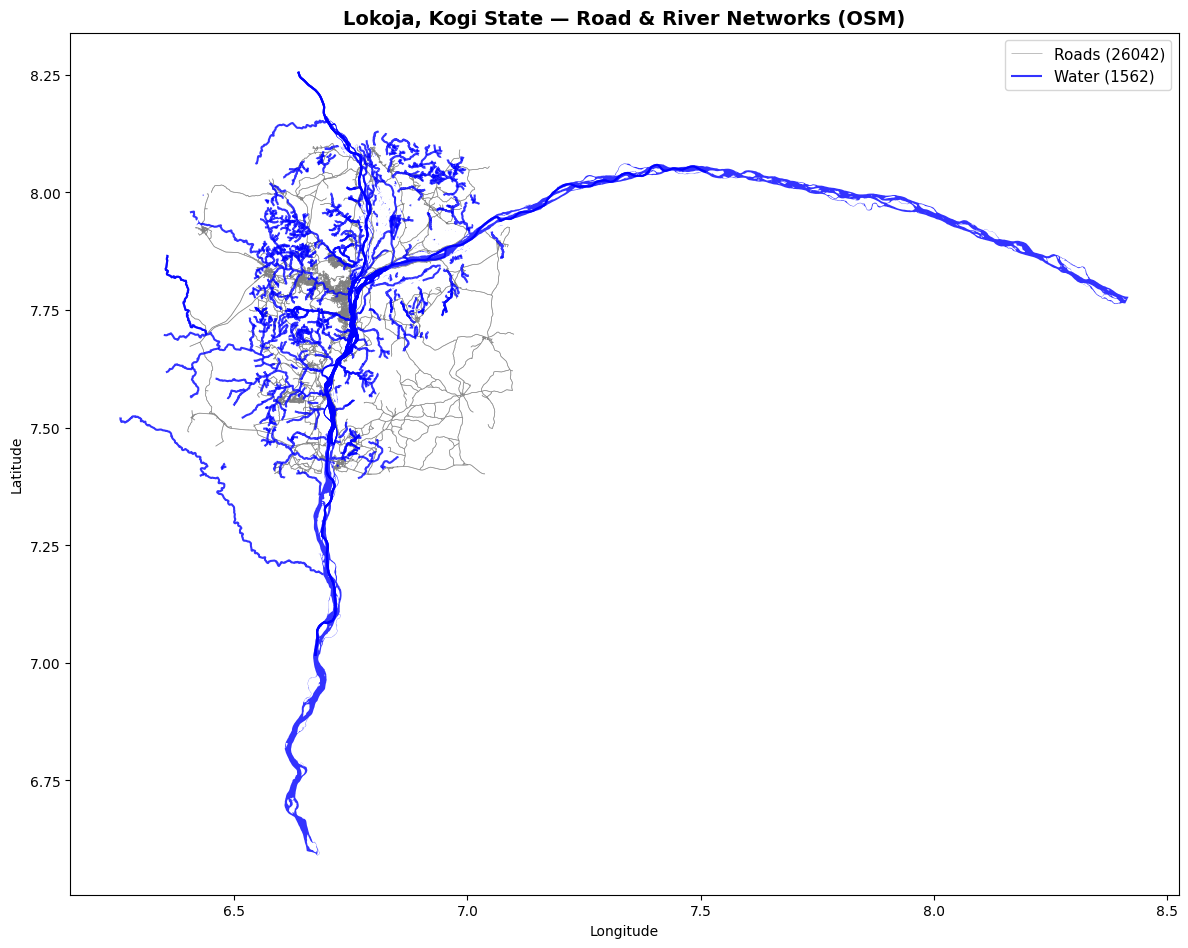

✅ Road and river networks saved


In [ ]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

print(f'osmnx version: {ox.__version__}')

# osmnx v2.0+ bbox format: (left, bottom, right, top) = (lon_min, lat_min, lon_max, lat_max)
bbox_osmnx = (
    STUDY_AREA['lon_min'],  # left  / west
    STUDY_AREA['lat_min'],  # bottom / south
    STUDY_AREA['lon_max'],  # right  / east
    STUDY_AREA['lat_max']   # top   / north
)

# ---- Roads Network ----
print('Downloading road network from OpenStreetMap...')
G_roads = ox.graph_from_bbox(bbox=bbox_osmnx, network_type='drive')
roads_gdf = ox.graph_to_gdfs(G_roads, nodes=False)
print(f'  ✅ Roads: {len(roads_gdf)} road segments')

# ---- Water Features ----
print('Downloading water features (rivers, streams)...')
water_tags = {'natural': 'water', 'waterway': ['river', 'stream', 'canal']}
try:
    water_gdf = ox.features_from_bbox(bbox=bbox_osmnx, tags=water_tags)
    print(f'  ✅ Water features: {len(water_gdf)} features')
except Exception as e:
    print(f'  ⚠️  Water features: {e}')
    water_gdf = gpd.GeoDataFrame()

# ---- Save ----
roads_gdf.to_file('/content/kogi_roads.gpkg', driver='GPKG')
if len(water_gdf) > 0:
    water_gdf.to_file('/content/kogi_water.gpkg', driver='GPKG')
print('  ✅ Files saved')

# ---- Plot ----
fig, ax = plt.subplots(figsize=(12, 10))
roads_gdf.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.7, label=f'Roads ({len(roads_gdf)})')

if len(water_gdf) > 0:
    valid_types = ['LineString', 'MultiLineString', 'Polygon', 'MultiPolygon']
    water_plot = water_gdf[water_gdf.geometry.geom_type.isin(valid_types)]
    if len(water_plot) > 0:
        water_plot.plot(ax=ax, color='blue', linewidth=1.5, alpha=0.8, label=f'Water ({len(water_plot)})')

ax.set_title('Lokoja, Kogi State — Road & River Networks (OSM)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('/content/kogi_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Road and river networks saved')

## 🔲 Step 11: Create Spatial Grid (Graph Nodes)

✅ Spatial grid created: 24336 nodes (tiles)
   Grid dimensions: 156 cols × 156 rows
   Tile size: ~500m × 500m


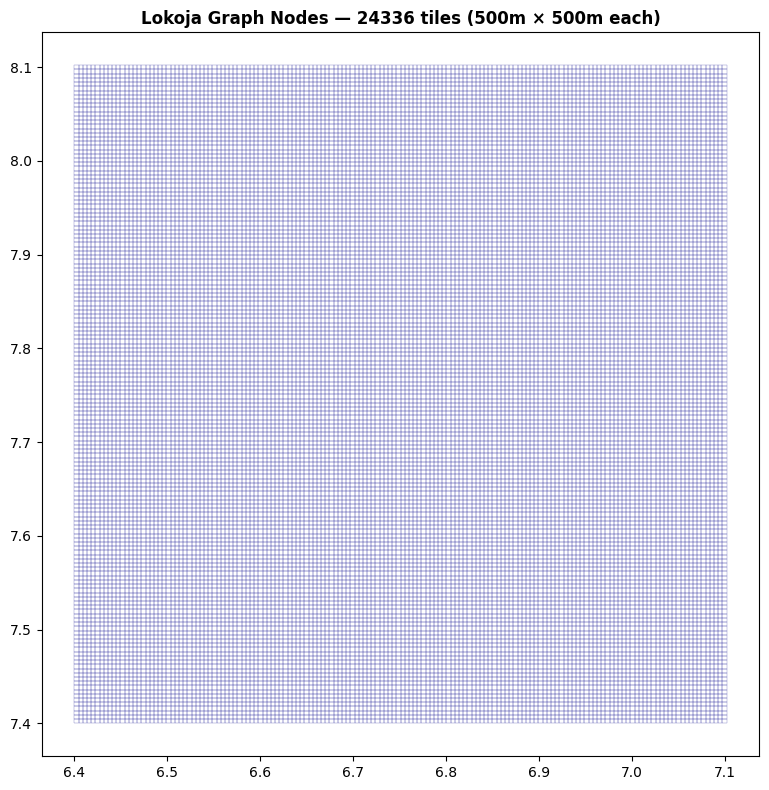

In [ ]:
import geopandas as gpd
from shapely.geometry import box
import numpy as np
import pandas as pd

# ============================================================
# CREATE 500m × 500m GRID TILES = GRAPH NODES
# Each tile becomes one node in the spatial graph
# ============================================================

TILE_SIZE_DEG = 0.0045  # ~500m at this latitude

lon_range = np.arange(STUDY_AREA['lon_min'], STUDY_AREA['lon_max'], TILE_SIZE_DEG)
lat_range = np.arange(STUDY_AREA['lat_min'], STUDY_AREA['lat_max'], TILE_SIZE_DEG)

tiles = []
for i, lon in enumerate(lon_range):
    for j, lat in enumerate(lat_range):
        geom = box(lon, lat, lon + TILE_SIZE_DEG, lat + TILE_SIZE_DEG)
        centroid = geom.centroid
        tiles.append({
            'node_id': len(tiles),
            'grid_col': i,
            'grid_row': j,
            'centroid_lon': centroid.x,
            'centroid_lat': centroid.y,
            'geometry': geom
        })

nodes_gdf = gpd.GeoDataFrame(tiles, crs='EPSG:4326')

print(f'✅ Spatial grid created: {len(nodes_gdf)} nodes (tiles)')
print(f'   Grid dimensions: {len(lon_range)} cols × {len(lat_range)} rows')
print(f'   Tile size: ~500m × 500m')

# Save
nodes_gdf.to_file('/content/kogi_nodes.gpkg', driver='GPKG')

# Plot the grid
fig, ax = plt.subplots(figsize=(10, 8))
nodes_gdf.boundary.plot(ax=ax, linewidth=0.3, color='darkblue', alpha=0.5)
ax.set_title(f'Lokoja Graph Nodes — {len(nodes_gdf)} tiles (500m × 500m each)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/kogi_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔗 Step 12: Build Graph Edges (Spatial Adjacency + River/Road Connections)

In [ ]:
import torch
from scipy.spatial import cKDTree

# ============================================================
# EDGE CONSTRUCTION STRATEGY:
#   Type 1: Queen adjacency (8 neighbors) — spatial proximity
#   Type 2: Road connectivity — nodes with shared road segments
#   Type 3: River connectivity — nodes with shared river segments
# ============================================================

node_positions = nodes_gdf[['centroid_lon', 'centroid_lat']].values
node_ids = nodes_gdf['node_id'].values
n_nodes = len(nodes_gdf)

edges = []
edge_types = []

# ---- TYPE 1: Queen adjacency (8-connected grid neighbors) ----
grid_cols = nodes_gdf['grid_col'].values
grid_rows = nodes_gdf['grid_row'].values
col_to_idx = {(r, c): i for i, (r, c) in enumerate(zip(grid_rows, grid_cols))}

neighbors_added = 0
for idx, row in nodes_gdf.iterrows():
    r, c = row['grid_row'], row['grid_col']
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if dr == 0 and dc == 0:
                continue
            neighbor_key = (r + dr, c + dc)
            if neighbor_key in col_to_idx:
                neighbor_idx = col_to_idx[neighbor_key]
                edges.append([row['node_id'], neighbor_idx])
                edge_types.append(0)  # type 0 = spatial adjacency
                neighbors_added += 1

print(f'  Queen adjacency edges: {neighbors_added}')

# ---- TYPE 2: Road connectivity ----
# Nodes that share a road segment get a road-type edge
try:
    roads_gdf_loaded = gpd.read_file('/content/kogi_roads.gpkg')
    road_edges = 0
    for _, road in roads_gdf_loaded.iterrows():
        road_geom = road.geometry
        if road_geom is None:
            continue
        # Find nodes that intersect or are within 250m buffer of road
        road_buf = road_geom.buffer(0.002)  # ~220m buffer
        intersecting = nodes_gdf[nodes_gdf.geometry.intersects(road_buf)]['node_id'].tolist()
        for i in range(len(intersecting) - 1):
            edges.append([intersecting[i], intersecting[i+1]])
            edge_types.append(1)  # type 1 = road connection
            road_edges += 1
    print(f'  Road connectivity edges: {road_edges}')
except Exception as e:
    print(f'  Road edges: skipped ({e})')

# Convert to PyG edge_index format
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_attr  = torch.tensor(edge_types, dtype=torch.long).unsqueeze(1)

print(f'\n✅ Graph structure built!')
print(f'   Nodes: {n_nodes}')
print(f'   Total edges: {len(edges)}')
print(f'   Edge index shape: {edge_index.shape}')

# Save graph structure
torch.save({'edge_index': edge_index, 'edge_attr': edge_attr, 'n_nodes': n_nodes},
           '/content/kogi_graph_structure.pt')
print('   Saved: /content/kogi_graph_structure.pt')

  Queen adjacency edges: 192820
  Road connectivity edges: 91828

✅ Graph structure built!
   Nodes: 24336
   Total edges: 284648
   Edge index shape: torch.Size([2, 284648])
   Saved: /content/kogi_graph_structure.pt


## 📊 Step 13: Visualize Study Area with All Layers

In [ ]:
# Interactive GEE map with all layers
Map2 = geemap.Map(center=[7.75, 6.75], zoom=10)

# Sentinel-2 RGB
Map2.addLayer(s2_wet.select(['B4','B3','B2']),
              {'min': 0, 'max': 0.3}, 'Sentinel-2 RGB (Wet Season)')

# NDVI
Map2.addLayer(s2_wet.select('NDVI'),
              {'min': -0.2, 'max': 0.8, 'palette': ['red','yellow','green']}, 'NDVI')

# MNDWI (water index)
Map2.addLayer(s2_wet.select('MNDWI'),
              {'min': -1, 'max': 1, 'palette': ['brown','white','blue']}, 'MNDWI (Water)')

# Sentinel-1 VV
Map2.addLayer(s1_flood.select('VV'),
              {'min': -25, 'max': 0}, 'S1 VV (Flood Period)')

# Flood mask
Map2.addLayer(flood_mask.selfMask(),
              {'palette': ['blue']}, 'Flood Detected (S1)')

# Elevation
Map2.addLayer(elevation,
              {'min': 40, 'max': 400, 'palette': ['blue','green','yellow','brown','white']}, 'Elevation (DEM)')

# JRC Flood Risk Labels
Map2.addLayer(flood_risk_label,
              {'min': 0, 'max': 3, 'palette': ['white','yellow','orange','red']}, 'Flood Risk Labels (JRC)')

Map2.addLayerControl()
Map2

Map(center=[7.75, 6.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

## ✅ Phase 1 Complete!

**What we accomplished:**
- ✅ Sentinel-1 SAR loaded (flood change detection)
- ✅ Sentinel-2 multispectral loaded (NDVI, NDWI, MNDWI, EVI)
- ✅ SRTM DEM loaded (elevation, slope, TWI)
- ✅ JRC flood labels created (4-class risk)
- ✅ 19-band feature stack built
- ✅ Feature stack exported to Google Drive
- ✅ OSM road + river networks downloaded
- ✅ 500m × 500m spatial grid = graph nodes
- ✅ Graph edges built (Queen adjacency + road connectivity)

**Next: Phase 2 — CNN Feature Extraction & Node Feature Matrix**

```
Phase 1: Data ✅  →  Phase 2: CNN features  →  Phase 3: GAT  →  Phase 4: Transformer  →  Phase 5: Output
```
